In [1]:
1

1

# Pose Landmarks Detection with MediaPipe Tasks

This notebook shows you how to use MediaPipe Tasks Python API to detect pose landmarks from images.

## Visualization utilities

In [1]:
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision


def draw_landmarks_on_image(bgr_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(bgr_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

In [2]:
# 추출 순서 = draw_landmarks에 전달될 새 인덱스 순서
BODY18_MP_INDICES = [
    5,   # 0: right_eye
    8,   # 1: right_ear
    11,  # 2: left_shoulder
    12,  # 3: right_shoulder
    13,  # 4: left_elbow
    14,  # 5: right_elbow
    15,  # 6: left_wrist
    16,  # 7: right_wrist
    23,  # 8: left_hip
    24,  # 9: right_hip
    25,  # 10: left_knee
    26,  # 11: right_knee
    27,  # 12: left_ankle
    28,  # 13: right_ankle
    31,  # 14: left_toe
    32,  # 15: right_toe
    29,  # 16: left_heel
    30,  # 17: right_heel
]

# 위의 새 인덱스(0~17) 기준 연결
BODY18_LINKS = [
    (0, 1), (1, 3),
    (2, 3),
    (2, 4), (4, 6),
    (3, 5), (5, 7),
    (2, 8), (3, 9), (8, 9),
    (8, 10), (10, 12),
    (9, 11), (11, 13),
    (12, 14), (12, 16),
    (13, 15), (13, 17),
]

BODY18_CONNECTIONS = [
    vision.PoseLandmarksConnections.Connection(start, end)
    for start, end in BODY18_LINKS
]

In [5]:
def draw_landmarks_on_image(bgr_image, detection_result):
    annotated_image = np.copy(bgr_image)

    pose_landmark_style = drawing_utils.DrawingSpec(
        color=(0, 80, 255), thickness=2, circle_radius=3
    )
    pose_connection_style = drawing_utils.DrawingSpec(
        color=(0, 255, 0), thickness=2
    )

    for pose_landmarks in detection_result.pose_landmarks:
        # 원본 MediaPipe 33개 중 원하는 18개만 추출
        body18_landmarks = [
            pose_landmarks[index]
            for index in BODY18_MP_INDICES
        ]

        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=body18_landmarks,       # 18개만 전달
            connections=BODY18_CONNECTIONS,       # 0~17 기준 연결
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style,
        )

    return annotated_image

In [10]:
vision.PoseLandmarksConnections.POSE_LANDMARKS

[PoseLandmarksConnections.Connection(start=0, end=1),
 PoseLandmarksConnections.Connection(start=1, end=2),
 PoseLandmarksConnections.Connection(start=2, end=3),
 PoseLandmarksConnections.Connection(start=3, end=7),
 PoseLandmarksConnections.Connection(start=0, end=4),
 PoseLandmarksConnections.Connection(start=4, end=5),
 PoseLandmarksConnections.Connection(start=5, end=6),
 PoseLandmarksConnections.Connection(start=6, end=8),
 PoseLandmarksConnections.Connection(start=9, end=10),
 PoseLandmarksConnections.Connection(start=11, end=12),
 PoseLandmarksConnections.Connection(start=11, end=13),
 PoseLandmarksConnections.Connection(start=13, end=15),
 PoseLandmarksConnections.Connection(start=15, end=17),
 PoseLandmarksConnections.Connection(start=15, end=19),
 PoseLandmarksConnections.Connection(start=15, end=21),
 PoseLandmarksConnections.Connection(start=17, end=19),
 PoseLandmarksConnections.Connection(start=12, end=14),
 PoseLandmarksConnections.Connection(start=14, end=16),
 PoseLand

In [3]:
CUSTOM_CONNECTIONS = [
    # 오른눈 → 오른귀 → 오른어깨
    (5, 8), (8, 12),

    # 왼어깨 ↔ 오른어깨
    (11, 12),

    # 양팔
    (11, 13), (13, 15),
    (12, 14), (14, 16),

    # 상체와 골반
    (11, 23), (12, 24), (23, 24),

    # 양다리
    (23, 25), (25, 27),
    (24, 26), (26, 28),

    # 발목 → 발가락 끝 / 뒤꿈치
    (27, 31), (27, 29),
    (28, 32), (28, 30),
]

CUSTOM_CONNECTIONS = [
    vision.PoseLandmarksConnections.Connection(start, end)
    for start, end in CUSTOM_CONNECTIONS
]

In [4]:
CUSTOM_CONNECTIONS

[PoseLandmarksConnections.Connection(start=5, end=8),
 PoseLandmarksConnections.Connection(start=8, end=12),
 PoseLandmarksConnections.Connection(start=11, end=12),
 PoseLandmarksConnections.Connection(start=11, end=13),
 PoseLandmarksConnections.Connection(start=13, end=15),
 PoseLandmarksConnections.Connection(start=12, end=14),
 PoseLandmarksConnections.Connection(start=14, end=16),
 PoseLandmarksConnections.Connection(start=11, end=23),
 PoseLandmarksConnections.Connection(start=12, end=24),
 PoseLandmarksConnections.Connection(start=23, end=24),
 PoseLandmarksConnections.Connection(start=23, end=25),
 PoseLandmarksConnections.Connection(start=25, end=27),
 PoseLandmarksConnections.Connection(start=24, end=26),
 PoseLandmarksConnections.Connection(start=26, end=28),
 PoseLandmarksConnections.Connection(start=27, end=31),
 PoseLandmarksConnections.Connection(start=27, end=29),
 PoseLandmarksConnections.Connection(start=28, end=32),
 PoseLandmarksConnections.Connection(start=28, end=

## Download test image

To demonstrate the Pose Landmarker API, you can download a sample image using the follow code. The image is from [Pixabay](https://pixabay.com/photos/girl-woman-fitness-beautiful-smile-4051811/).

In [6]:
# !wget -q -O image.jpg https://cdn.pixabay.com/photo/2019/03/12/20/39/girl-4051811_960_720.jpg

import cv2

img = cv2.imread("image.jpg")

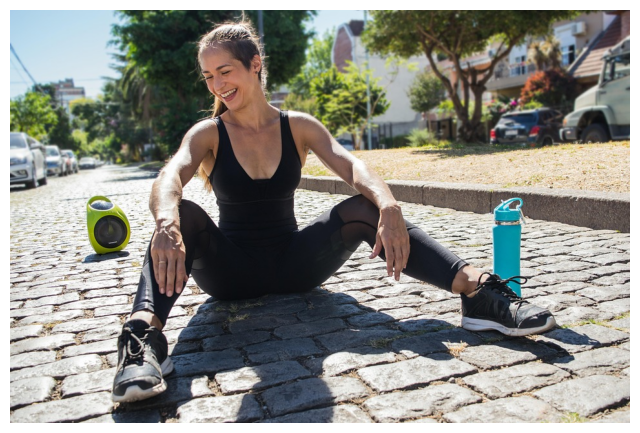

In [7]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("image.jpg")
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Optionally, you can upload your own image. If you want to do so, uncomment and run the cell below.

In [ ]:
# from google.colab import files
# uploaded = files.upload()

# for filename in uploaded:
#   content = uploaded[filename]
#   with open(filename, 'wb') as f:
#     f.write(content)

# if len(uploaded.keys()):
#   IMAGE_FILE = next(iter(uploaded))
#   print('Uploaded file:', IMAGE_FILE)

## Running inference and visualizing the results

The final step is to run pose landmark detection on your selected image. This involves creating your PoseLandmarker object, loading your image, running detection, and finally, the optional step of displaying the image with visualizations.

Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker/python) to learn more about configuration options that this solution supports.


I0000 00:00:1787048343.616224 53798117 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 19, prefix = pthread-default
I0000 00:00:1787048343.648224 53798117 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787048343.683975 53798125 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787048343.696647 53798119 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787048343.722027 53798135 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


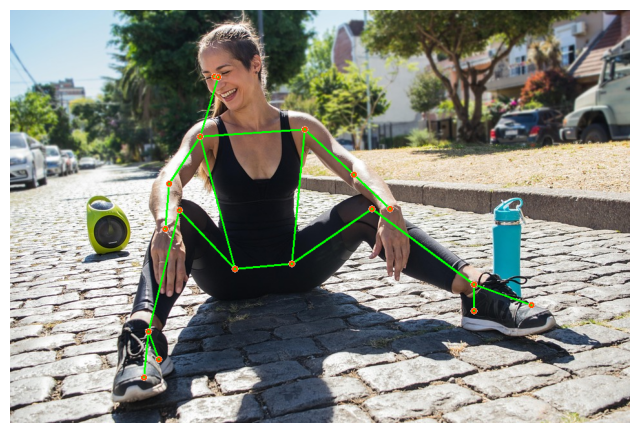

In [8]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.3,
    min_pose_presence_confidence=0.3,
    min_tracking_confidence=0.3,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("image.jpg")

# STEP 4: VIDEO mode requires a monotonically increasing timestamp.
detection_result = detector.detect_for_video(image, timestamp_ms=0)

# STEP 5: Process the detection result. In this case, visualize it.
# BGR 3채널로 변환 후 랜드마크 그리기
bgr_image = cv2.cvtColor(image.numpy_view(), cv2.COLOR_RGBA2BGR)
annotated_image = draw_landmarks_on_image(bgr_image, detection_result)

# matplotlib은 RGB를 기대
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Visualize the pose segmentation mask.

In [8]:
segmentation_mask = detection_result.segmentation_masks[0].numpy_view()
segmentation_mask = np.squeeze(segmentation_mask)

# Convert to 3‑channel uint8 image for visualization.
visualized_mask = (segmentation_mask * 255).astype(np.uint8)
visualized_mask = np.stack([visualized_mask]*3, axis=-1)

In [9]:
visualized_mask

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(640, 960, 3), dtype=uint8)

In [6]:
from pathlib import Path
import json
import cv2
import mediapipe as mp

IMAGE_EXTENSIONS = {".bmp", ".jpeg", ".jpg", ".png", ".webp"}

BODY18_KEYPOINTS = [
    ("right_eye", 5), ("right_ear", 8),
    ("left_shoulder", 11), ("right_shoulder", 12),
    ("left_elbow", 13), ("right_elbow", 14),
    ("left_wrist", 15), ("right_wrist", 16),
    ("left_hip", 23), ("right_hip", 24),
    ("left_knee", 25), ("right_knee", 26),
    ("left_ankle", 27), ("right_ankle", 28),
    ("left_toe", 31), ("right_toe", 32),
    ("left_heel", 29), ("right_heel", 30),
]


def process_mediapipe_image_folder(detector, input_dir, output_dir, fps):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    rendered_dir = output_dir / "rendered"

    if fps <= 0:
        raise ValueError("fps는 0보다 커야 합니다.")

    if not input_dir.is_dir():
        raise NotADirectoryError(f"입력 폴더가 없습니다: {input_dir}")

    rendered_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(
        path for path in input_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    frames = []

    # timestamp 0은 위 단일 이미지 예제에서 사용했으므로 1부터 시작합니다.
    for frame_index, image_path in enumerate(image_paths, start=1):
        # 1. MediaPipe 추론용 이미지
        mp_image = mp.Image.create_from_file(str(image_path))
        timestamp_ms = round(frame_index * 1000 / fps)
        detection_result = detector.detect_for_video(
            mp_image, timestamp_ms=timestamp_ms
        )

        # 2. 결과 이미지용 BGR 원본
        bgr_image = cv2.imread(str(image_path))
        if bgr_image is None:
            print(f"건너뜀: 이미지를 읽을 수 없음: {image_path.name}")
            continue

        # 3. 이전에 만든 Body18 전용 draw 함수 호출
        annotated_image = draw_landmarks_on_image(
            bgr_image, detection_result
        )

        # 4. 그려진 이미지 저장
        output_image_path = rendered_dir / image_path.name
        cv2.imwrite(str(output_image_path), annotated_image)

        # 5. 사람별 Body18 좌표만 JSON용으로 추출
        people = []
        for pose_landmarks in detection_result.pose_landmarks:
            keypoints = []
            for name, mp_index in BODY18_KEYPOINTS:
                landmark = pose_landmarks[mp_index]
                keypoints.append({
                    "name": name,
                    "x": landmark.x,  # 0~1 정규화 좌표
                    "y": landmark.y,
                    "z": landmark.z,
                    "visibility": landmark.visibility,
                    "presence": landmark.presence,
                })
            people.append({"keypoints": keypoints})

        frames.append({
            "image_name": image_path.name,
            "timestamp_ms": timestamp_ms,
            "people": people,
        })

    result = {
        "model": "MediaPipe Pose Landmarker",
        "format": "mediapipe_body18_v1",
        "keypoint_names": [name for name, _ in BODY18_KEYPOINTS],
        "frames": frames,
    }

    json_path = output_dir / "pose_predictions.json"
    json_path.write_text(
        json.dumps(result, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print(f"처리 이미지 수: {len(frames)}")
    print(f"렌더링 결과: {rendered_dir}")
    print(f"키포인트 JSON: {json_path}")

    return result

In [7]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path='pose_landmarker_heavy.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.3,
    min_pose_presence_confidence=0.3,
    min_tracking_confidence=0.3,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

I0000 00:00:1787048659.659916 53810821 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 19, prefix = pthread-default
I0000 00:00:1787048659.696184 53810821 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787048659.732828 53810833 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787048659.746118 53810834 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [8]:
result = process_mediapipe_image_folder(
    detector,
    input_dir="/Users/hyeon/SeSAC_Project/RTMPose-MPS/inputs/videos/test1/frames",
    output_dir="/Users/hyeon/SeSAC_Project/MediaPipe/outputs/test1",
    fps=25,
)

W0000 00:00:1787048660.675020 53810828 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


처리 이미지 수: 500
렌더링 결과: /Users/hyeon/SeSAC_Project/MediaPipe/outputs/test1/rendered
키포인트 JSON: /Users/hyeon/SeSAC_Project/MediaPipe/outputs/test1/pose_predictions.json
